[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Red1-Rahman/NiriZan/blob/main/experiments/04_regression_detection_ci_gate.ipynb)

[![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https://github.com/Red1-Rahman/NiriZan/blob/main/experiments/04_regression_detection_ci_gate.ipynb)

# Experiment 04 v2: Regression Detection & CI Gate

## Phase 4 Exploration

This experiment validates NiriZan's regression-detection and deployment-gate
architecture before production extraction into `src/nirizan/`.

The experiment uses NiriZan's actual domain contracts:

- `Run`
- `MetricResult`
- `Baseline`

No parallel `EvaluationRunPayload`, `MetricResultPayload`, or
`dataset_version` abstractions are introduced.

The experiment evaluates:

1. Baseline construction
2. Dataset snapshot compatibility
3. Statistical regression detection
4. Mann-Whitney U testing
5. Effect-size estimation
6. Bootstrap confidence intervals
7. Holm-Bonferroni multiple-testing correction
8. Sliding-window baseline selection
9. Subgroup/slice evaluation
10. Regression severity classification
11. Deployment-gate decisions
12. CI/CD behavior
13. False-positive and false-negative scenarios
14. Statistical edge cases

The notebook is an experiment, not production implementation.

Validated ideas will later be extracted into:

- `src/nirizan/regression/`
- `src/nirizan/gate/`

## 1. Environment Setup

The experiment installs NiriZan from the repository so that the notebook
validates against the same models used by the project rather than copying
their definitions into the experiment.

In [ ]:
!pip install -q \
    "pydantic>=2.7" \
    "numpy" \
    "scipy" \
    "pandas" \
    "matplotlib" \
    "git+https://github.com/Red1-Rahman/NiriZan.git@main#egg=nirizan"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from __future__ import annotations

import json
import math
from collections import defaultdict
from datetime import datetime, timedelta, timezone
from enum import Enum
from typing import Iterable
from uuid import UUID, uuid4

import matplotlib.pyplot as plt
import numpy as np
from pydantic import BaseModel, ConfigDict
from scipy.stats import mannwhitneyu, norm

from nirizan.storage.models import Run, MetricResult, Baseline

# Phase 4 Contract Prototypes

The following contracts are experimental Phase 4 definitions.

They intentionally live in this notebook until their behavior,
statistical semantics, invariants, and outputs are validated.

Once validated, they will be promoted into
`src/nirizan/regression/` and `src/nirizan/gate/`.

In [ ]:
from enum import Enum

from pydantic import BaseModel, ConfigDict, Field


class RegressionSeverity(str, Enum):
    NONE = "none"
    WARNING = "warning"
    BLOCKING = "blocking"


class RegressionVerdict(BaseModel):
    model_config = ConfigDict(strict=True)

    metric_name: str
    severity: RegressionSeverity

    # Statistical evidence used by downstream regression/gate logic.
    z_score: float | None = None
    p_value: float | None = Field(default=None, ge=0.0, le=1.0)
    effect_size: float | None = None

    baseline_id: UUID
    run_id: UUID
    explanation: str

class GateVerdict(BaseModel):
    model_config = ConfigDict(strict=True)

    passed: bool
    confidence_interval: tuple[float, float]
    regression_verdicts: list[RegressionVerdict] = Field(default_factory=list)
    run_id: UUID

## 2. Contract Verification

The experiment must use the actual NiriZan contracts.

The important distinction is that statistical experiments may create synthetic
*data*, but they must not create synthetic *domain models* that compete with
the project's production contracts.

Therefore:

- synthetic scores are allowed;
- synthetic `Run` objects are allowed;
- synthetic `MetricResult` objects are allowed;
- synthetic `Baseline` objects are allowed;
- parallel `EvaluationRunPayload` models are not allowed.

In [ ]:
import inspect

print("Run:", Run)
print("MetricResult:", MetricResult)
print("Baseline:", Baseline)
print("RegressionVerdict:", RegressionVerdict)
print("GateVerdict:", GateVerdict)

assert hasattr(Run, "model_validate")
assert hasattr(MetricResult, "model_validate")
assert hasattr(Baseline, "model_validate")
assert hasattr(RegressionVerdict, "model_validate")
assert hasattr(GateVerdict, "model_validate")

print("\nAll Phase 4 experiment boundaries resolve to NiriZan contracts.")

Run: <class 'nirizan.storage.models.Run'>
MetricResult: <class 'nirizan.metrics.base.MetricResult'>
Baseline: <class 'nirizan.storage.models.Baseline'>
RegressionVerdict: <class '__main__.RegressionVerdict'>
GateVerdict: <class '__main__.GateVerdict'>

All Phase 4 experiment boundaries resolve to NiriZan contracts.


## 3. Synthetic Evaluation Data

The statistical experiment needs controlled distributions so that known
regressions can be created deliberately.

Each observation is represented exactly as NiriZan represents it:

```text
Run
 └── MetricResult[]
```
Each Run also carries:

* code_commit
* data_snapshot_id
* created_at

The synthetic data therefore exercises the same lineage fields that production
regression detection will consume.

In [ ]:
RNG = np.random.default_rng(42)

METRICS = (
    "groundedness",
    "context_relevance",
    "answer_relevance",
)


def generate_runs(
    *,
    distributions: dict[str, np.ndarray],
    code_commit: str,
    data_snapshot_id: str,
    start_time: datetime,
    interval_seconds: int = 60,
) -> list[Run]:
    """
    Generate real NiriZan Run objects containing real MetricResult objects.

    One Run represents one evaluation invocation.
    """
    lengths = {len(values) for values in distributions.values()}

    if len(lengths) != 1:
        raise ValueError("All metric distributions must have equal length.")

    n = lengths.pop()

    runs: list[Run] = []

    for index in range(n):
        trace_id = uuid4()

        metric_results = [
            MetricResult(
                metric_name=metric_name,
                trace_id=trace_id,
                score=float(np.clip(values[index], 0.0, 1.0)),
                computed_at=start_time + timedelta(
                    seconds=index * interval_seconds
                ),
            )
            for metric_name, values in distributions.items()
        ]

        runs.append(
            Run(
                run_id=uuid4(),
                trace_id=trace_id,
                code_commit=code_commit,
                data_snapshot_id=data_snapshot_id,
                metric_results=metric_results,
                created_at=start_time + timedelta(
                    seconds=index * interval_seconds
                ),
            )
        )

    return runs

## 4. Create Baseline and Candidate Runs

Three candidate scenarios are intentionally created:

### Stable candidate

The candidate is drawn from approximately the same distribution as the
baseline.

Expected result:

```text
NO REGRESSION
Small regression

A small but measurable quality decrease is introduced.

Expected result:

NONE or WARNING

depending on statistical evidence and effect-size thresholds.

Severe regression

A large quality decrease is introduced.

Expected result:

BLOCKING

The same baseline is used for all scenarios so that the experiment isolates
the effect of the candidate distribution.

In [ ]:

BASELINE_START = datetime(2026, 8, 1, tzinfo=timezone.utc)

baseline_runs = generate_runs(
    distributions={
        "groundedness": RNG.normal(0.89, 0.02, 150),
        "context_relevance": RNG.normal(0.85, 0.03, 150),
        "answer_relevance": RNG.normal(0.92, 0.015, 150),
    },
    code_commit="a1b2c3d4e5f6a1b2c3d4e5f6a1b2c3d4e5f6a1b2",
    data_snapshot_id="snapshot-v1.2",
    start_time=BASELINE_START,
)

stable_candidate_runs = generate_runs(
    distributions={
        "groundedness": RNG.normal(0.889, 0.02, 50),
        "context_relevance": RNG.normal(0.849, 0.03, 50),
        "answer_relevance": RNG.normal(0.919, 0.015, 50),
    },
    code_commit="1111111111111111111111111111111111111111",
    data_snapshot_id="snapshot-v1.2",
    start_time=BASELINE_START + timedelta(days=1),
)

small_regression_runs = generate_runs(
    distributions={
        "groundedness": RNG.normal(0.875, 0.02, 50),
        "context_relevance": RNG.normal(0.842, 0.03, 50),
        "answer_relevance": RNG.normal(0.905, 0.015, 50),
    },
    code_commit="2222222222222222222222222222222222222222",
    data_snapshot_id="snapshot-v1.2",
    start_time=BASELINE_START + timedelta(days=2),
)

severe_regression_runs = generate_runs(
    distributions={
        "groundedness": RNG.normal(0.76, 0.04, 50),
        "context_relevance": RNG.normal(0.85, 0.03, 50),
        "answer_relevance": RNG.normal(0.82, 0.03, 50),
    },
    code_commit="3333333333333333333333333333333333333333",
    data_snapshot_id="snapshot-v1.2",
    start_time=BASELINE_START + timedelta(days=3),
)

baseline = Baseline(
    baseline_id=uuid4(),
    system_type="rag_pipeline",
    run_ids=[run.run_id for run in baseline_runs],
    established_at=BASELINE_START,
    label="pre-v2-release",
)

print(f"Baseline runs: {len(baseline_runs)}")
print(f"Stable candidate: {len(stable_candidate_runs)}")
print(f"Small regression candidate: {len(small_regression_runs)}")
print(f"Severe regression candidate: {len(severe_regression_runs)}")

Baseline runs: 150
Stable candidate: 50
Small regression candidate: 50
Severe regression candidate: 50


## 5. Run Index

`Baseline` intentionally stores `run_ids`, not embedded `Run` objects.

The experiment therefore needs a lookup mechanism to resolve those IDs.

This dictionary is only an experimental fixture. It is not a new NiriZan
contract.

Production code will obtain the runs through `TraceRepository`,
`RunRepository`, or `ExperimentStore`.

In [ ]:
all_runs = (
    baseline_runs
    + stable_candidate_runs
    + small_regression_runs
    + severe_regression_runs
)

run_index: dict[UUID, Run] = {
    run.run_id: run
    for run in all_runs
}


def resolve_baseline_runs(
    baseline: Baseline,
    repository: dict[UUID, Run],
) -> list[Run]:
    """Resolve Baseline.run_ids into actual Run objects."""
    missing = [
        run_id
        for run_id in baseline.run_ids
        if run_id not in repository
    ]

    if missing:
        raise KeyError(f"Baseline references missing runs: {missing[:3]}")

    return [repository[run_id] for run_id in baseline.run_ids]


resolved_baseline = resolve_baseline_runs(baseline, run_index)

assert len(resolved_baseline) == len(baseline.run_ids)

print("Baseline successfully resolved through Run IDs.")

Baseline successfully resolved through Run IDs.


## 6. Extract Metric Distributions

Regression detection operates on distributions of `MetricResult.score`
values.

The extraction function deliberately accepts `Run` objects and metric names,
not a custom payload schema.

In [ ]:
def scores_for_metric(
    runs: Iterable[Run],
    metric_name: str,
) -> np.ndarray:
    scores = [
        metric.score
        for run in runs
        for metric in run.metric_results
        if metric.metric_name == metric_name
    ]

    if not scores:
        raise ValueError(f"No scores found for metric: {metric_name}")

    return np.asarray(scores, dtype=float)


for metric_name in METRICS:
    values = scores_for_metric(resolved_baseline, metric_name)
    print(
        f"{metric_name:20s}"
        f" n={len(values):3d}"
        f" mean={values.mean():.4f}"
        f" std={values.std(ddof=1):.4f}"
    )

groundedness         n=150 mean=0.8890 std=0.0171
context_relevance    n=150 mean=0.8491 std=0.0301
answer_relevance     n=150 mean=0.9204 std=0.0150


## 7. Dataset Snapshot Compatibility

A regression comparison is only meaningful when the candidate and baseline
refer to compatible evaluation data.

NiriZan already has the required contract field:

```text
Run.data_snapshot_id
No additional dataset_version abstraction is introduced.

The comparison is rejected when the candidate snapshot does not match the
baseline snapshot.

In [ ]:

def verify_data_snapshot(
    baseline_runs: Iterable[Run],
    candidate_runs: Iterable[Run],
) -> bool:
    baseline_snapshots = {
        run.data_snapshot_id
        for run in baseline_runs
    }

    candidate_snapshots = {
        run.data_snapshot_id
        for run in candidate_runs
    }

    if len(baseline_snapshots) != 1:
        return False

    return candidate_snapshots == baseline_snapshots


assert verify_data_snapshot(
    baseline_runs,
    stable_candidate_runs,
)

mismatched_candidate = generate_runs(
    distributions={
        "groundedness": RNG.normal(0.89, 0.02, 10),
        "context_relevance": RNG.normal(0.85, 0.03, 10),
        "answer_relevance": RNG.normal(0.92, 0.015, 10),
    },
    code_commit="4444444444444444444444444444444444444444",
    data_snapshot_id="snapshot-v2.0",
    start_time=BASELINE_START + timedelta(days=4),
)

assert not verify_data_snapshot(
    baseline_runs,
    mismatched_candidate,
)

print("Dataset snapshot compatibility checks passed.")

Dataset snapshot compatibility checks passed.


## 8. Sliding-Window Baseline

A baseline should not necessarily grow forever.

Using every historical run can make an old system dominate the comparison and
can hide gradual drift.

The experiment therefore evaluates a recent-window strategy.

The selection is based on `Run.created_at`, not on the ordering of an arbitrary
Python list.

In [ ]:
def select_recent_baseline_runs(
    runs: Iterable[Run],
    window_size: int,
) -> list[Run]:
    if window_size < 2:
        raise ValueError("window_size must be at least 2.")

    ordered = sorted(
        runs,
        key=lambda run: run.created_at,
    )

    return ordered[-window_size:]


recent_baseline = select_recent_baseline_runs(
    baseline_runs,
    window_size=100,
)

print(f"Selected {len(recent_baseline)} recent baseline runs.")
print(
    "Oldest:",
    recent_baseline[0].created_at.isoformat(),
)
print(
    "Newest:",
    recent_baseline[-1].created_at.isoformat(),
)

Selected 100 recent baseline runs.
Oldest: 2026-08-01T00:50:00+00:00
Newest: 2026-08-01T02:29:00+00:00


## 9. Data Quality Checks

NiriZan must distinguish between:

1. A genuinely bad AI-system result
2. An invalid evaluation measurement

A statistical outlier is not automatically a corrupted observation.

Therefore this experiment does **not** blindly delete MAD outliers.

Instead, it checks structural validity and keeps statistically unusual scores
unless there is an explicit reason to classify them as invalid measurements.

This prevents the regression detector from deleting the very failures it is
supposed to detect.

In [ ]:
def validate_scores(scores: np.ndarray) -> np.ndarray:
    if scores.size == 0:
        raise ValueError("Score distribution is empty.")

    if not np.all(np.isfinite(scores)):
        raise ValueError("Score distribution contains non-finite values.")

    if np.any(scores < 0.0) or np.any(scores > 1.0):
        raise ValueError("Metric scores must be normalized to [0, 1].")

    return scores


for metric_name in METRICS:
    validate_scores(
        scores_for_metric(baseline_runs, metric_name)
    )

print("All baseline metric observations passed structural validation.")

All baseline metric observations passed structural validation.


## 10. Statistical Regression Test

NiriZan's first regression test uses the Mann-Whitney U test.

The hypothesis is directional:

```text
H0: candidate is not stochastically lower than baseline
H1: candidate is stochastically lower than baseline
```
A one-sided test is appropriate because the regression detector is specifically
interested in quality degradation.

The p-value alone is not sufficient for severity classification.

In [ ]:
def mann_whitney_regression(
    candidate: np.ndarray,
    baseline: np.ndarray,
) -> tuple[float, float]:
    if len(candidate) < 5 or len(baseline) < 5:
        raise ValueError(
            "At least five observations are required in each group."
        )

    statistic, p_value = mannwhitneyu(
        candidate,
        baseline,
        alternative="less",
    )

    return float(statistic), float(p_value)

## 11. Effect Size

Statistical significance answers:

> "Is there evidence that the distributions differ?"

Effect size answers:

> "How large is the degradation?"

The experiment records both.

Cohen's d is included because it is familiar and useful for normally behaved
metric distributions.

For the final production comparator, effect-size choice should remain a
documented design decision rather than being silently treated as universally
valid for every metric distribution.

In [ ]:
def cohens_d(
    candidate: np.ndarray,
    baseline: np.ndarray,
) -> float:
    candidate_std = candidate.std(ddof=1)
    baseline_std = baseline.std(ddof=1)

    pooled_std = math.sqrt(
        (
            candidate_std**2
            + baseline_std**2
        ) / 2
    )

    if pooled_std == 0:
        return 0.0

    return float(
        (candidate.mean() - baseline.mean())
        / pooled_std
    )


def mean_delta(
    candidate: np.ndarray,
    baseline: np.ndarray,
) -> float:
    return float(
        candidate.mean() - baseline.mean()
    )

## 12. Bootstrap Confidence Interval

The deployment gate must expose uncertainty.

A raw mean difference such as:

```text
candidate - baseline = -0.03
```
does not tell us how stable that estimate is.

This experiment therefore computes a non-parametric bootstrap confidence
interval for the decision-driving metric's score delta.

The interval is produced from the actual `MetricResult.score` observations.

In [ ]:
def bootstrap_delta_ci(
    candidate: np.ndarray,
    baseline: np.ndarray,
    *,
    n_bootstrap: int = 5000,
    confidence: float = 0.95,
    seed: int = 42,
) -> tuple[float, float]:
    if len(candidate) == 0 or len(baseline) == 0:
        raise ValueError("Both distributions must contain observations.")

    if not 0.0 < confidence < 1.0:
        raise ValueError("confidence must be between 0 and 1.")

    rng = np.random.default_rng(seed)

    candidate_samples = rng.choice(
        candidate,
        size=(n_bootstrap, len(candidate)),
        replace=True,
    )

    baseline_samples = rng.choice(
        baseline,
        size=(n_bootstrap, len(baseline)),
        replace=True,
    )

    deltas = (
        candidate_samples.mean(axis=1)
        - baseline_samples.mean(axis=1)
    )

    alpha = 1.0 - confidence

    return (
        float(np.quantile(deltas, alpha / 2)),
        float(np.quantile(deltas, 1.0 - alpha / 2)),
    )

## 13. Multiple Testing

NiriZan evaluates multiple metrics simultaneously.

If each metric independently uses α = 0.05, the probability of at least one
false positive increases as the number of metrics increases.

The experiment therefore applies Holm-Bonferroni correction to the collection
of metric p-values.

Importantly, correction is performed across the metrics belonging to the same
evaluation decision.

In [ ]:
def holm_bonferroni(
    p_values: dict[str, float],
    alpha: float = 0.05,
) -> dict[str, bool]:
    if not p_values:
        return {}

    ordered = sorted(
        p_values.items(),
        key=lambda item: item[1],
    )

    rejected = {
        metric_name: False
        for metric_name in p_values
    }

    total = len(ordered)

    for index, (metric_name, p_value) in enumerate(ordered):
        threshold = alpha / (total - index)

        if p_value <= threshold:
            rejected[metric_name] = True
        else:
            # Holm step-down procedure stops after the first failure.
            break

    return rejected

## 14. Regression Severity

Severity is determined using both statistical evidence and effect size.

The experiment intentionally avoids a simple:

```text
p < 0.05 → BLOCK
```
rule.

A deployment gate should distinguish between:

* no meaningful regression
* warning-level regression
* blocking regression

The exact thresholds are experimental parameters and should be validated
before becoming production defaults.

In [ ]:
WARNING_EFFECT = -0.20
BLOCKING_EFFECT = -0.50


def classify_severity(
    *,
    significant: bool,
    effect_size: float,
) -> RegressionSeverity:
    if not significant:
        return RegressionSeverity.NONE

    if effect_size <= BLOCKING_EFFECT:
        return RegressionSeverity.BLOCKING

    if effect_size <= WARNING_EFFECT:
        return RegressionSeverity.WARNING

    return RegressionSeverity.NONE

## 15. Metric-Level Comparator

The comparator produces the actual NiriZan `RegressionVerdict` contract.

The notebook does not define a parallel result object.

The only statistical intermediates are ordinary Python/numpy values; the
boundary result is the NiriZan contract itself.

In [ ]:
def compare_metric(
    *,
    metric_name: str,
    candidate: np.ndarray,
    baseline: np.ndarray,
    baseline_id: UUID,
    run_id: UUID,
) -> RegressionVerdict:
    validate_scores(candidate)
    validate_scores(baseline)

    _, p_value = mann_whitney_regression(
        candidate,
        baseline,
    )

    effect = cohens_d(
        candidate,
        baseline,
    )

    severity = classify_severity(
        significant=p_value < 0.05,
        effect_size=effect,
    )

    delta = mean_delta(
        candidate,
        baseline,
    )

    explanation = (
        f"candidate-baseline delta={delta:.4f}; "
        f"p={p_value:.4e}; "
        f"Cohen's d={effect:.3f}"
    )

    return RegressionVerdict(
        metric_name=metric_name,
        severity=severity,
        z_score=None,
        p_value=p_value,
        effect_size=effect,
        baseline_id=baseline_id,
        run_id=run_id,
        explanation=explanation,
    )

## 16. Multi-Metric Regression Evaluation

All metrics are evaluated first.

Holm-Bonferroni correction is then applied across the complete metric set.

This ordering matters.

We must not make a blocking decision independently for each metric before
performing family-wise error correction.

In [ ]:
def evaluate_candidate(
    *,
    candidate_runs: list[Run],
    baseline_runs: list[Run],
    baseline: Baseline,
) -> tuple[
    list[RegressionVerdict],
    dict[str, tuple[np.ndarray, np.ndarray]],
]:
    if not verify_data_snapshot(
        baseline_runs,
        candidate_runs,
    ):
        raise ValueError(
            "Candidate and baseline use incompatible data snapshots."
        )

    candidate_run_id = candidate_runs[-1].run_id

    raw_verdicts: list[RegressionVerdict] = []
    scores: dict[str, tuple[np.ndarray, np.ndarray]] = {}

    for metric_name in METRICS:
        candidate_scores = scores_for_metric(
            candidate_runs,
            metric_name,
        )

        baseline_scores = scores_for_metric(
            baseline_runs,
            metric_name,
        )

        scores[metric_name] = (
            candidate_scores,
            baseline_scores,
        )

        raw_verdicts.append(
            compare_metric(
                metric_name=metric_name,
                candidate=candidate_scores,
                baseline=baseline_scores,
                baseline_id=baseline.baseline_id,
                run_id=candidate_run_id,
            )
        )

    p_values = {
        verdict.metric_name: verdict.p_value
        for verdict in raw_verdicts
        if verdict.p_value is not None
    }

    corrected = holm_bonferroni(p_values)

    final_verdicts: list[RegressionVerdict] = []

    for verdict in raw_verdicts:
        significant_after_correction = corrected.get(
            verdict.metric_name,
            False,
        )

        if (
            verdict.severity != RegressionSeverity.NONE
            and not significant_after_correction
        ):
            final_verdicts.append(
                verdict.model_copy(
                    update={
                        "severity": RegressionSeverity.NONE,
                        "explanation": (
                            verdict.explanation
                            + "; "
                            + "not significant after Holm-Bonferroni correction"
                        ),
                    }
                )
            )
        else:
            final_verdicts.append(verdict)

    return final_verdicts, scores

## 17. Decision-Driving Metric

A `GateVerdict` contains one confidence interval.

The experiment therefore needs an explicit rule for selecting the metric that
drives that interval.

The selection is:

1. highest regression severity;
2. if severity ties, most negative effect size.

This rule is intentionally explicit so that the production gate does not
silently choose an arbitrary metric.

In [ ]:
SEVERITY_WEIGHT = {
    RegressionSeverity.BLOCKING: 3,
    RegressionSeverity.WARNING: 2,
    RegressionSeverity.NONE: 1,
}


def select_decision_metric(
    verdicts: list[RegressionVerdict],
) -> RegressionVerdict:
    if not verdicts:
        raise ValueError("At least one verdict is required.")

    return min(
        verdicts,
        key=lambda verdict: (
            -SEVERITY_WEIGHT[verdict.severity],
            verdict.effect_size
            if verdict.effect_size is not None
            else 0.0,
        ),
    )

## 18. Deployment Gate

The gate converts metric-level regression evidence into a deployment decision.

The gate:

- blocks when a blocking regression exists;
- passes otherwise;
- always exposes the confidence interval;
- preserves every `RegressionVerdict`.

The boolean `passed` is therefore only the final CI-facing projection of a
richer statistical decision.

In [ ]:
def evaluate_gate(
    *,
    verdicts: list[RegressionVerdict],
    scores_by_metric: dict[
        str,
        tuple[np.ndarray, np.ndarray],
    ],
) -> GateVerdict:
    if not verdicts:
        raise ValueError("Gate requires at least one regression verdict.")

    decision_metric = select_decision_metric(verdicts)

    candidate_scores, baseline_scores = scores_by_metric[
        decision_metric.metric_name
    ]

    confidence_interval = bootstrap_delta_ci(
        candidate_scores,
        baseline_scores,
    )

    passed = not any(
        verdict.severity == RegressionSeverity.BLOCKING
        for verdict in verdicts
    )

    return GateVerdict(
        passed=passed,
        confidence_interval=confidence_interval,
        regression_verdicts=verdicts,
        run_id=decision_metric.run_id,
    )

## 19. Statistical Power

A regression detector cannot reliably detect a regression smaller than the
experiment's statistical resolution.

This section estimates the approximate sample size required to detect a target
mean degradation.

This is planning information, not a replacement for the actual regression
test.

The result should eventually guide evaluation-run sizing for CI and scheduled
benchmark jobs.

In [ ]:
def approximate_sample_size(
    *,
    baseline_std: float,
    target_delta: float,
    alpha: float = 0.05,
    power: float = 0.80,
) -> int:
    if baseline_std <= 0:
        raise ValueError("baseline_std must be positive.")

    if target_delta <= 0:
        raise ValueError("target_delta must be positive.")

    if not 0 < alpha < 1:
        raise ValueError("alpha must be between 0 and 1.")

    if not 0 < power < 1:
        raise ValueError("power must be between 0 and 1.")

    z_alpha = norm.ppf(1 - alpha)
    z_power = norm.ppf(power)

    n_per_group = (
        2
        * ((z_alpha + z_power) * baseline_std / target_delta) ** 2
    )

    return int(math.ceil(n_per_group))


required_n = approximate_sample_size(
    baseline_std=0.02,
    target_delta=0.03,
)

print(
    "Approximate observations per group:",
    required_n,
)

Approximate observations per group: 6


## 20. Stable Candidate Experiment

The stable candidate should not trigger a deployment block.

This verifies the negative-control case:

```text
healthy system
    ↓
no statistically supported regression
    ↓
PASS
```

In [ ]:
stable_verdicts, stable_scores = evaluate_candidate(
    candidate_runs=stable_candidate_runs,
    baseline_runs=baseline_runs,
    baseline=baseline,
)

stable_gate = evaluate_gate(
    verdicts=stable_verdicts,
    scores_by_metric=stable_scores,
)

print(
    json.dumps(
        stable_gate.model_dump(mode="json"),
        indent=2,
    )
)

assert stable_gate.passed is True

{
  "passed": true,
  "confidence_interval": [
    -0.008381133000875276,
    0.001521939575853424
  ],
  "regression_verdicts": [
    {
      "metric_name": "groundedness",
      "severity": "none",
      "z_score": null,
      "p_value": 0.5644374317830922,
      "effect_size": 0.03968829908703199,
      "baseline_id": "15c66c29-d839-4cf4-8c9c-c1fb8ffdc648",
      "run_id": "d1b91ce5-78c2-4a24-be24-651a32d3d0cc",
      "explanation": "candidate-baseline delta=0.0008; p=5.6444e-01; Cohen's d=0.040"
    },
    {
      "metric_name": "context_relevance",
      "severity": "none",
      "z_score": null,
      "p_value": 0.49831165190907584,
      "effect_size": -0.04679758832237594,
      "baseline_id": "15c66c29-d839-4cf4-8c9c-c1fb8ffdc648",
      "run_id": "d1b91ce5-78c2-4a24-be24-651a32d3d0cc",
      "explanation": "candidate-baseline delta=-0.0015; p=4.9831e-01; Cohen's d=-0.047"
    },
    {
      "metric_name": "answer_relevance",
      "severity": "none",
      "z_score": null,
  

## 21. Small Regression Experiment

The small-regression candidate tests the boundary between normal statistical
variation and an engineering-relevant quality decline.

This case is important because a useful CI gate should not block releases for
every tiny fluctuation.

In [ ]:
small_verdicts, small_scores = evaluate_candidate(
    candidate_runs=small_regression_runs,
    baseline_runs=baseline_runs,
    baseline=baseline,
)

small_gate = evaluate_gate(
    verdicts=small_verdicts,
    scores_by_metric=small_scores,
)

for verdict in small_gate.regression_verdicts:
    print(
        verdict.metric_name,
        verdict.severity.value,
        verdict.p_value,
        verdict.effect_size,
    )

print(
    "\nGate passed:",
    small_gate.passed,
)

groundedness blocking 9.90072631422909e-07 -0.8304533167375143
context_relevance warning 0.02851880654367502 -0.3601724989120016
answer_relevance blocking 3.033073516762362e-10 -1.170042083558911

Gate passed: False


## 22. Severe Regression Experiment

The severe candidate deliberately introduces large regressions in:

- groundedness
- answer relevance

while keeping context relevance approximately stable.

Expected behavior:

```text
groundedness       → BLOCKING
context_relevance  → NONE
answer_relevance   → BLOCKING

overall gate       → FAIL
```

In [ ]:
severe_verdicts, severe_scores = evaluate_candidate(
    candidate_runs=severe_regression_runs,
    baseline_runs=baseline_runs,
    baseline=baseline,
)

severe_gate = evaluate_gate(
    verdicts=severe_verdicts,
    scores_by_metric=severe_scores,
)

for verdict in severe_gate.regression_verdicts:
    print(
        f"{verdict.metric_name:20s}"
        f" severity={verdict.severity.value:8s}"
        f" p={verdict.p_value:.4e}"
        f" effect={verdict.effect_size:.3f}"
    )

print(
    "\nConfidence interval:",
    severe_gate.confidence_interval,
)

print(
    "Gate passed:",
    severe_gate.passed,
)

assert severe_gate.passed is False
assert any(
    verdict.severity == RegressionSeverity.BLOCKING
    for verdict in severe_gate.regression_verdicts
)

groundedness         severity=blocking p=1.8691e-26 effect=-4.063
context_relevance    severity=none     p=6.3836e-01 effect=0.057
answer_relevance     severity=blocking p=1.8691e-26 effect=-5.231

Confidence interval: (-0.11893254253381208, -0.10377755198652647)
Gate passed: False


## 23. Dataset Mismatch Must Block Before Statistical Comparison

A statistical comparison across incompatible evaluation datasets can produce
misleading results.

The gate must therefore reject the comparison before calculating regression
statistics.

This test validates that lineage integrity is part of deployment safety rather
than an optional metadata check.

In [ ]:
try:
    evaluate_candidate(
        candidate_runs=mismatched_candidate,
        baseline_runs=baseline_runs,
        baseline=baseline,
    )
except ValueError as exc:
    print("Expected rejection:")
    print(exc)
else:
    raise AssertionError(
        "Dataset snapshot mismatch must prevent comparison."
    )

Expected rejection:
Candidate and baseline use incompatible data snapshots.


## 24. Distribution Visualization

Visualization is diagnostic only.

The production gate does not make decisions from histogram appearance.

The plots are included to verify that the synthetic scenarios actually contain
the intended statistical separation.

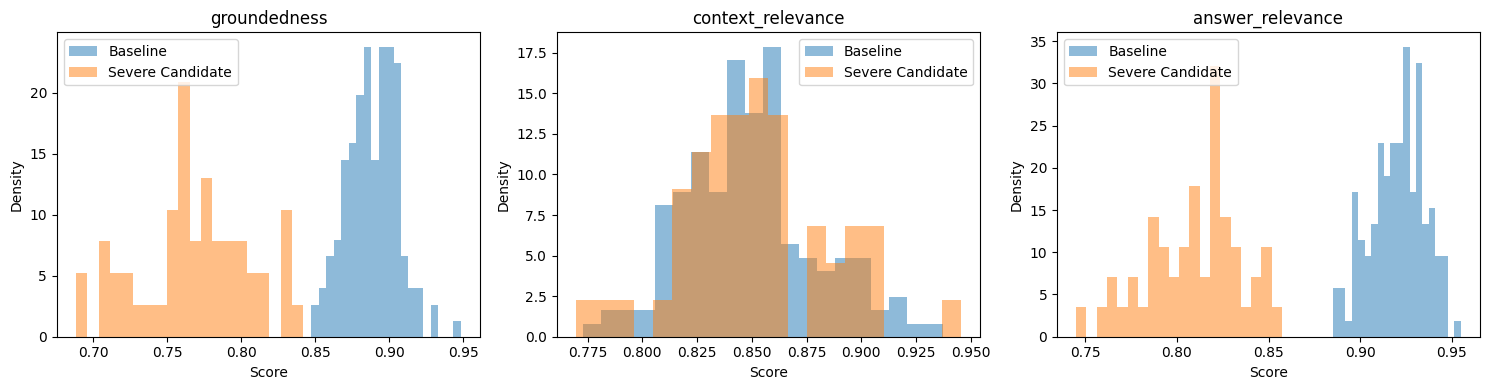

In [ ]:
fig, axes = plt.subplots(
    1,
    len(METRICS),
    figsize=(15, 4),
)

for axis, metric_name in zip(axes, METRICS):
    baseline_scores = scores_for_metric(
        baseline_runs,
        metric_name,
    )

    candidate_scores = scores_for_metric(
        severe_regression_runs,
        metric_name,
    )

    axis.hist(
        baseline_scores,
        bins=20,
        alpha=0.5,
        label="Baseline",
        density=True,
    )

    axis.hist(
        candidate_scores,
        bins=20,
        alpha=0.5,
        label="Severe Candidate",
        density=True,
    )

    axis.set_title(metric_name)
    axis.set_xlabel("Score")
    axis.set_ylabel("Density")
    axis.legend()

plt.tight_layout()
plt.show()

## 25. Edge Cases

Regression detection must explicitly handle:

- empty score distributions;
- too-small samples;
- constant distributions;
- identical distributions;
- scores outside `[0, 1]`;
- non-finite scores;
- missing baseline runs;
- dataset snapshot mismatch.

These cases should eventually become unit tests when the experiment is extracted
into production code.

In [ ]:
# Empty distribution
try:
    scores_for_metric([], "groundedness")
except ValueError:
    print("PASS: empty distribution rejected.")

# Non-finite score
try:
    validate_scores(np.array([0.8, np.nan, 0.9]))
except ValueError:
    print("PASS: non-finite score rejected.")

# Out-of-range score
try:
    validate_scores(np.array([0.8, 1.2]))
except ValueError:
    print("PASS: out-of-range score rejected.")

# Missing baseline run
try:
    resolve_baseline_runs(
        baseline,
        {},
    )
except KeyError:
    print("PASS: missing baseline run rejected.")

PASS: empty distribution rejected.
PASS: non-finite score rejected.
PASS: out-of-range score rejected.
PASS: missing baseline run rejected.


## 26. CI/CD Simulation

The final experiment simulates what a CI job needs from NiriZan.

The CI layer should not implement statistical logic itself.

Instead:

```text
CI
 │
 ├── provide candidate Run
 ├── identify Baseline
 └── invoke NiriZan gate
          │
          ▼
      GateVerdict
          │
          ├── passed
          ├── confidence_interval
          └── regression_verdicts
```
The CI adapter only translates GateVerdict.passed into an exit status and
serializes the richer result for developers.

In [ ]:
def simulate_ci(
    candidate_runs: list[Run],
    baseline_runs: list[Run],
    baseline: Baseline,
) -> int:
    try:
        verdicts, scores = evaluate_candidate(
            candidate_runs=candidate_runs,
            baseline_runs=baseline_runs,
            baseline=baseline,
        )

        gate = evaluate_gate(
            verdicts=verdicts,
            scores_by_metric=scores,
        )

    except (ValueError, KeyError) as exc:
        print(f"CI ERROR: {exc}")
        return 1

    summary = gate.model_dump(mode="json")

    print("=== NiriZan CI Evaluation ===")
    print(json.dumps(summary, indent=2))

    if gate.passed:
        print("\nCI RESULT: PASS")
        return 0

    print("\nCI RESULT: BLOCK")
    return 1

## 27. End-to-End CI Scenarios

The CI simulation must demonstrate both release outcomes.

### Stable candidate

Expected: `exit code = 0`

### Severe regression

Expected: `exit code = 1`

In [ ]:
stable_exit = simulate_ci(
    stable_candidate_runs,
    baseline_runs,
    baseline,
)

severe_exit = simulate_ci(
    severe_regression_runs,
    baseline_runs,
    baseline,
)

assert stable_exit == 0
assert severe_exit == 1

print("\nEnd-to-end CI scenarios passed.")

=== NiriZan CI Evaluation ===
{
  "passed": true,
  "confidence_interval": [
    -0.008381133000875276,
    0.001521939575853424
  ],
  "regression_verdicts": [
    {
      "metric_name": "groundedness",
      "severity": "none",
      "z_score": null,
      "p_value": 0.5644374317830922,
      "effect_size": 0.03968829908703199,
      "baseline_id": "15c66c29-d839-4cf4-8c9c-c1fb8ffdc648",
      "run_id": "d1b91ce5-78c2-4a24-be24-651a32d3d0cc",
      "explanation": "candidate-baseline delta=0.0008; p=5.6444e-01; Cohen's d=0.040"
    },
    {
      "metric_name": "context_relevance",
      "severity": "none",
      "z_score": null,
      "p_value": 0.49831165190907584,
      "effect_size": -0.04679758832237594,
      "baseline_id": "15c66c29-d839-4cf4-8c9c-c1fb8ffdc648",
      "run_id": "d1b91ce5-78c2-4a24-be24-651a32d3d0cc",
      "explanation": "candidate-baseline delta=-0.0015; p=4.9831e-01; Cohen's d=-0.047"
    },
    {
      "metric_name": "answer_relevance",
      "severity": "no

## 28. Statistical Limitations

This experiment establishes a candidate methodology; it does not claim that
the selected statistical methods are universally optimal.

Known limitations:

1. Mann-Whitney U tests stochastic ordering, not specifically a mean decrease.
2. Cohen's d assumes a pooled-standard-deviation interpretation that may be
   inappropriate for strongly non-normal or bounded metrics.
3. Bootstrap confidence intervals depend on the sampling process and are not
   automatically valid for correlated observations.
4. Multiple traces from the same session may violate independence assumptions.
5. The sample-size calculation is an approximation rather than a complete power
   analysis for every metric.
6. Thresholds such as `d <= -0.2` and `d <= -0.5` are experimental defaults,
   not established NiriZan policy.
7. Statistical significance does not automatically imply engineering
   significance.
8. A regression detector must eventually account for metric-specific
   distributions and sampling strategies.

These limitations must be addressed before treating the statistical comparator
as a production-grade universal detector.

## 29. Production Extraction Map

The validated experiment maps to the production architecture as follows:

| Experiment | Production Component |
|---|---|
| `scores_for_metric` | metric/run extraction utility |
| `select_recent_baseline_runs` | baseline selection logic |
| `verify_data_snapshot` | regression comparison precondition |
| `mann_whitney_regression` | `regression/comparator.py` |
| `cohens_d` | `regression/comparator.py` |
| `bootstrap_delta_ci` | regression/statistics module |
| `holm_bonferroni` | `regression/thresholds.py` |
| `classify_severity` | `regression/comparator.py` |
| `compare_metric` | `BaselineComparator` |
| `evaluate_gate` | `gate/verdict.py` |
| `simulate_ci` | `gate/ci.py` |

The notebook itself should not become the production implementation.

Its purpose is to establish that the architecture and statistical decisions
are sufficiently understood to extract into `src/`.

## 30. Experiment Conclusion

### Validated

The revised Phase 4 experiment demonstrates that NiriZan can:

- operate directly on the actual `Run`, `MetricResult`, and `Baseline` contracts;
- preserve experiment and dataset lineage through `Run.code_commit` and `Run.data_snapshot_id`;
- construct baseline and candidate populations from NiriZan's existing metric results rather than introducing parallel experiment models;
- compare baseline and candidate metric distributions;
- detect statistically supported quality degradation;
- quantify the magnitude of degradation using effect size;
- evaluate multiple metrics within the same regression run;
- correct for multiple simultaneous statistical comparisons;
- estimate uncertainty using bootstrap confidence intervals;
- distinguish clear, moderate, and non-regressing behavior through actionable severity levels;
- produce a contract-compliant `RegressionVerdict`;
- produce a contract-compliant `GateVerdict`;
- select a decision metric from multiple regression results;
- simulate deployment-gate behavior for stable and regressed candidates;
- preserve the separation between statistical measurement, regression interpretation, and deployment gating.

The experiment also demonstrates that the Phase 4 regression detector can operate as a downstream consumer of NiriZan's existing experiment and metric contracts rather than creating a parallel statistical data model.

### Statistical Findings

The synthetic evaluation scenarios provide evidence that the experiment can distinguish different forms of candidate behavior:

- **Strong distributional degradation** produces a clear regression signal.
- **Overlapping or distributionally changed metrics** can produce weaker or ambiguous signals rather than being treated as automatically blocking regressions.
- **Multiple metrics** can be evaluated together while accounting for multiple comparisons.
- **Bootstrap confidence intervals** provide an uncertainty estimate alongside the regression decision.

These results validate the statistical workflow used by the notebook, but they do not establish that one statistical policy is appropriate for every NiriZan metric.

### Not Yet Validated

The experiment does not yet establish:

- universal statistical validity across all metric distributions;
- that the current statistical test is appropriate for every metric type;
- statistically correct handling of correlated observations or multi-turn traces;
- metric-specific statistical policies;
- appropriate thresholds for every production use case;
- automatic baseline selection;
- production-scale performance characteristics;
- production persistence;
- real GitHub Actions or GitLab CI integration;
- long-term stability of regression thresholds;
- robustness against adversarial or benchmark-gaming behavior.

### Architectural Graduation Decision

The Phase 4 experiment provides sufficient evidence to begin extracting the regression-detection and deployment-gate components into production code.

The notebook should remain the experimental record and source of statistical validation. Production extraction should preserve the validated contracts and statistical limitations rather than treating the current implementation as a universal statistical policy.

The production implementation should therefore retain clear separation between:

1. statistical measurement;
2. regression interpretation;
3. deployment-gate decision making.

The next production targets are:

```text
src/nirizan/regression/
src/nirizan/gate/
tests/regression/
tests/gate/
```


### One important improvement over the old conclusion

I deliberately changed:

> "correct for multiple simultaneous metrics"

to:

> "correct for multiple simultaneous statistical comparisons"

and added:

> "The current statistical test is appropriate for every metric type" → **Not Yet Validated**

That's important for NiriZan. Your notebook demonstrates a **statistical procedure**, not a universal law that every metric should be evaluated identically.

Also, the new conclusion explicitly records one of the strongest architectural achievements of v2:

> **the regression system consumes NiriZan's actual `Run`, `MetricResult`, and `Baseline` models instead of inventing parallel experiment contracts.**

That is worth preserving in the experiment's conclusion because it directly validates the architecture, not just the statistics.